In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from collections import namedtuple

Region = namedtuple("domain", ["y0", "y1","x0","x1","name","rotation"],
                    defaults=[1,1,1,1,"d", "horizontal"])

Regions = []
Regions.append(Region(20,  36,  85, 121,"Cascades",'vertical')) 
Regions.append(Region(42,  62,  89, 117,"Northern Rockies",'vertical'))

Regions.append(Region(74,  91,  55,  90,"Central Great Plains",'vertical'))

Regions.append(Region(104, 133,  66,  93,"Midwest"))

Regions.append(Region(139, 166,  80, 116,"Northeast"))

Regions.append(Region(134, 155,  28,  69 ,"Southeast"))

Regions.append(Region(94, 128,  39,  63,"Gulf States"))

Regions.append(Region(51,  70,  26,  68,"North American monsoon",'vertical'))

In [12]:
vname = "AT2M"
#vname = "PRAVG"

#fname_obs = f"/mnt/gfs01/sun.chao/Climate/conventional/daily/OBS_{vname}_daily.nc"
if vname=="AT2M":
    new_name = {
    "lat":"south_north",
    "lon":"west_east",
    "day":"time",
    "y":"south_north",
    "x":"west_east",
    "air_temperature":"AT2M",
}
    fname_obs = "/mnt/gfs01/sun.chao/Climate/conventional/cwrfreporj/tave_daily_cwrf.nc"
else:
    fname_obs = "/mnt/gfs01/sun.chao/Climate/conventional/cwrfreporj/pr_daily_cwrf.nc"
    new_name = {
    "lat":"south_north",
    "lon":"west_east",
    "day":"time",
    "y":"south_north",
    "x":"west_east",
    "precipitation_amount":"PRAVG"
}
    
with xr.open_dataset(fname_obs) as ds_obs:
    ds_obs = ds_obs.rename(new_name).drop_vars(["lon_bnds","lat_bnds"])[vname]



In [13]:
fname = "//home/sun.chao/CROP_MODEL/dssat-csm-os-opt/wrfinput_d01"
ds_lm = xr.open_dataset(fname) 


fname = f"/mnt/gfs01/sun.chao/zafix5/zafix5_{vname}_daily.nc"
ds_cwrf = xr.open_dataset(fname)
ds_cwrf = ds_cwrf[vname].squeeze().where(ds_lm["LANDMASK"].isel(Time=0)==1)

def region_mean(ds):
    region_m = {}
    for region in Regions:
        south_north= slice(region.x0,region.x1)
        west_east  = slice(region.y0,region.y1)
        region_m[region.name] = ds.isel(
            south_north=south_north,
            west_east  = west_east        
        ).mean(["south_north","west_east"],skipna=True).to_pandas()
    return pd.concat(region_m, axis=1)

region_m_cwrf = region_mean(ds_cwrf)
region_m_obs  = region_mean(ds_obs)
region_m = pd.concat([region_m_obs,region_m_cwrf], axis=1, join="inner", keys=["obs", "cwrf"])
region_m = region_m.swaplevel(axis=1)

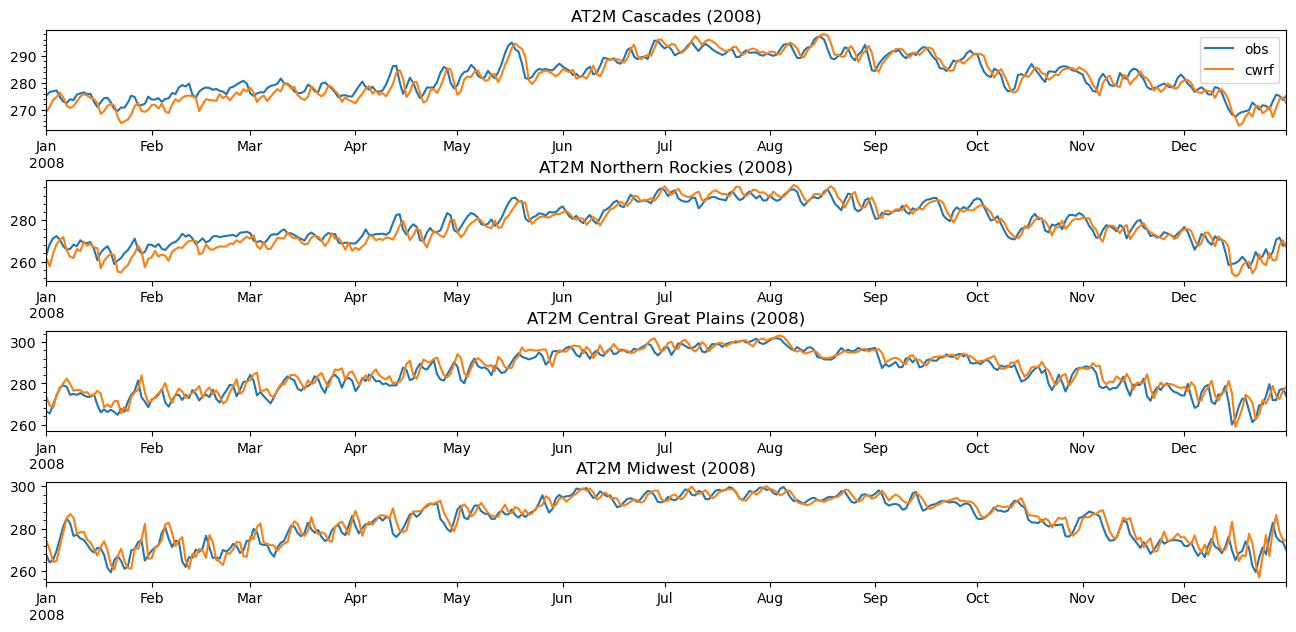

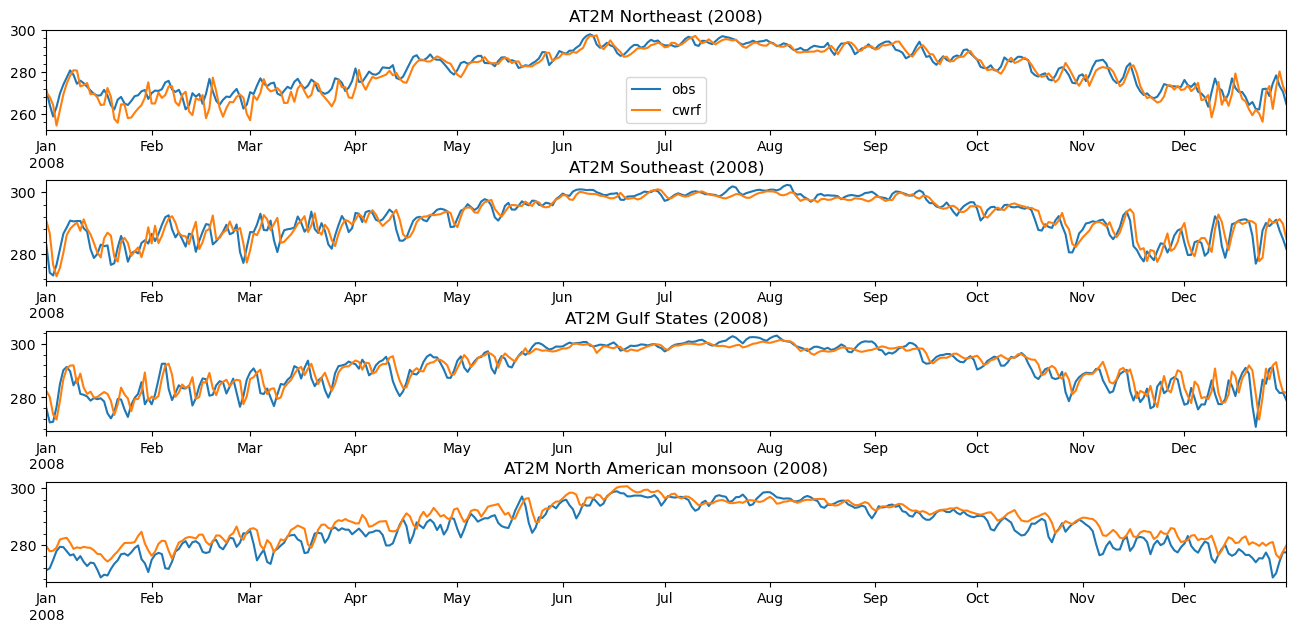

In [15]:

ylims_all = {}
ylims_all["PRAVG"] = {
    "Cascades":40,
    "Northern Rockies":20,
    "Central Great Plains":30,
    "Midwest":30,
    "Northeast": 40,
    "Southeast":30,
    "Gulf States":40,
    "North American monsoon":20,
    
}


#ylims = ylims_all[vname]

#for year in range(1979,2020):
for year in range(2008,2009):    
    fig = plt.figure(figsize=(16,15))
    gs0 = gridspec.GridSpec(8,1)
    gs0.update(hspace=0.5, wspace=0.5)
    for ireg,region in enumerate(Regions[:4]):
        ax = plt.subplot(gs0[ireg])    
        ax.yaxis.set_minor_locator( AutoMinorLocator(5))

        legend = False if ireg >0 else True
        df = region_m[region.name]
        df = df[df.index.year==year]
        df.plot(ax=ax,legend=legend)#ax=axs[ireg])

        title = f"{vname} {region.name} ({year})"

        plt.title(title)
        plt.ylabel("")
        plt.xlabel("")
        #plt.xticks([])
        plt.tick_params(
        axis='x',          # changes apply to the x-axis
        which='minor',      # both major and minor ticks are affected
        bottom=False,      # ticks along the bottom edge are off
        top=False,         # ticks along the top edge are off
        labelbottom=False) # labels along the bottom edge are off
        #plt.ylim([0,ylims[region.name] ])
    plt.savefig(f"figures/daily/TS_{vname}_{year}_daily_1.pdf")     
    #plt.close()


    fig = plt.figure(figsize=(16,15))

    gs0 = gridspec.GridSpec(8,1)
    gs0.update(hspace=0.5, wspace=0.5)
    for ireg,region in enumerate(Regions[4:]):
        ax = plt.subplot(gs0[ireg])    
        ax.yaxis.set_minor_locator( AutoMinorLocator(5))
        legend = False if ireg >0 else True
        df = region_m[region.name]
        df = df[df.index.year==year]
        df.plot(ax=ax,legend=legend)#ax=axs[ireg])

        title = f"{vname} {region.name} ({year})"

        plt.title(title)
        plt.ylabel("")
        plt.xlabel("")
        #plt.xticks([])
        plt.tick_params(
        axis='x',          # changes apply to the x-axis
        which='minor',      # both major and minor ticks are affected
        bottom=False,      # ticks along the bottom edge are off
        top=False,         # ticks along the top edge are off
        labelbottom=False) # labels along the bottom edge are off
        #plt.ylim([0,ylims[region.name] ])
    plt.savefig(f"figures/daily/TS_{vname}_{year}_daily_2.pdf")     
    #plt.close()

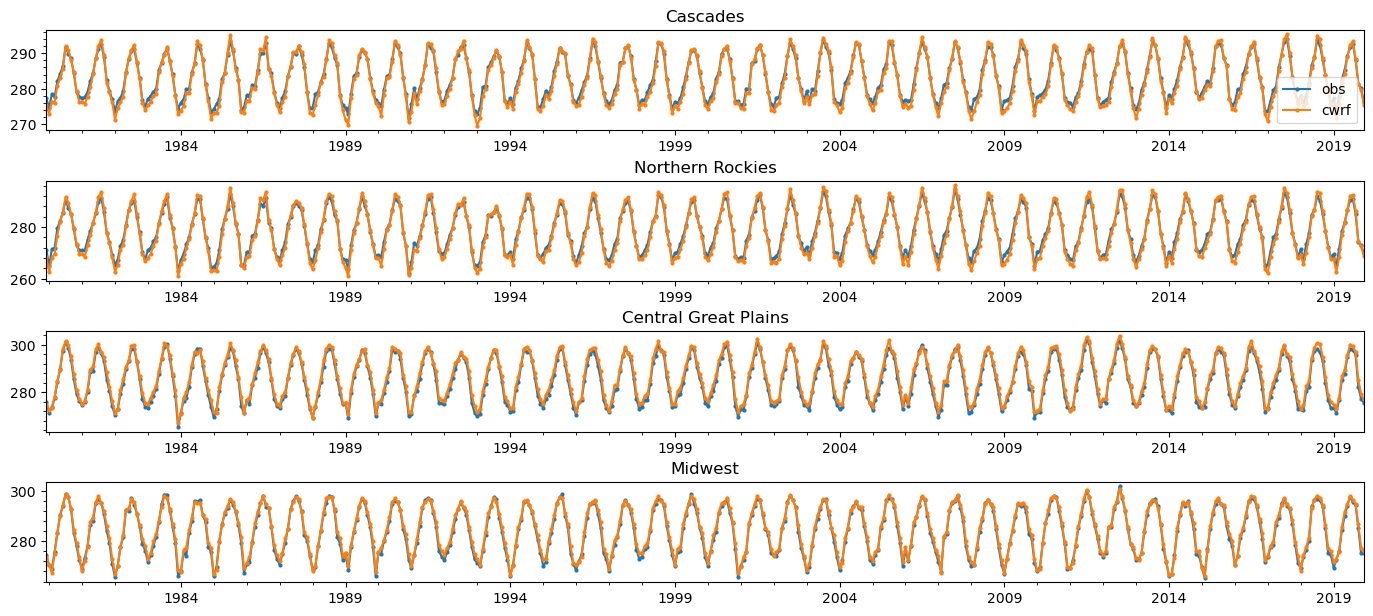

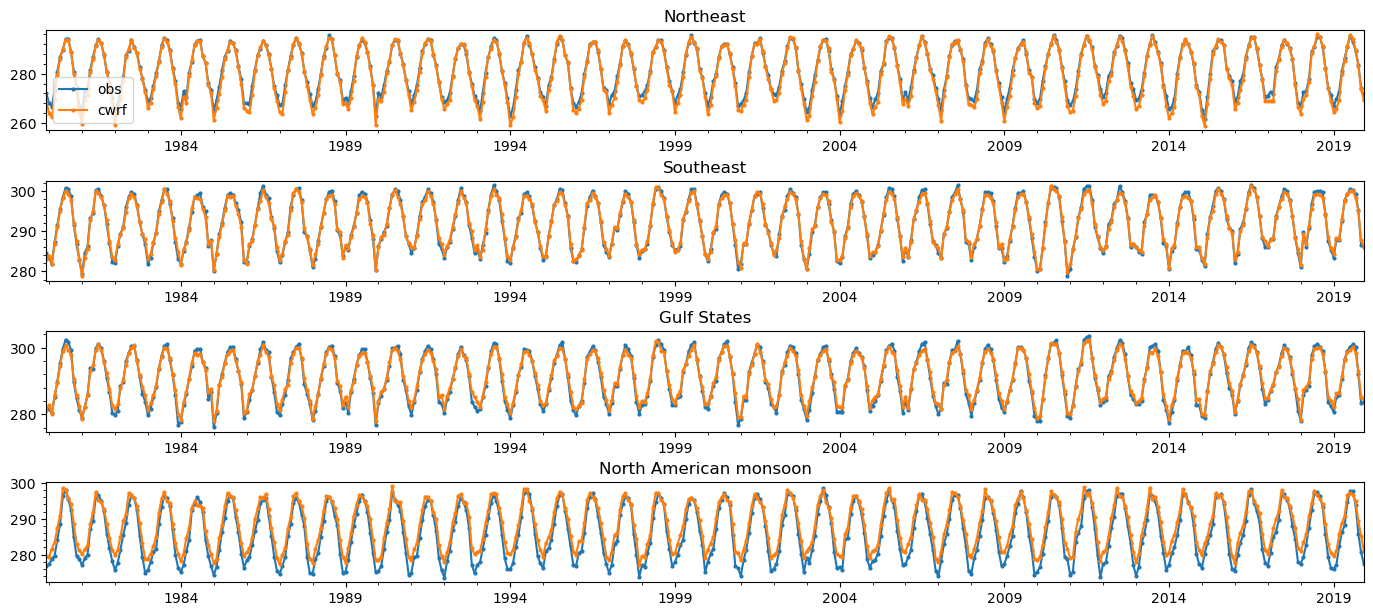

In [16]:

ylims_all["PRAVG"] = {
    "Cascades":20,
    "Northern Rockies":10,
    "Central Great Plains":10,
    "Midwest":10,
    "Northeast": 10,
    "Southeast":10,
    "Gulf States":10,
    "North American monsoon":10,
    
}

fig = plt.figure(figsize=(17,15))
gs0 = gridspec.GridSpec(8,1)
gs0.update(hspace=0.5, wspace=0.5)
for ireg,region in enumerate(Regions[:4]):
    ax = plt.subplot(gs0[ireg])    
    ax.yaxis.set_minor_locator( AutoMinorLocator(5))
    legend = False if ireg >0 else True
    region_m[region.name].resample('M').mean().plot(ax=ax,legend=legend,style="-o",ms=2)#ax=axs[ireg])
    plt.title(region.name)
    plt.ylabel("")
    plt.xlabel("")
    
plt.savefig(f"TS_{vname}_monthly_1.pdf")    




fig = plt.figure(figsize=(17,15))
gs0 = gridspec.GridSpec(8,1)
gs0.update(hspace=0.5, wspace=0.5)
for ireg,region in enumerate(Regions[4:]):
    ax = plt.subplot(gs0[ireg])    
    ax.yaxis.set_minor_locator( AutoMinorLocator(5))
    legend = False if ireg >0 else True
    region_m[region.name].resample('M').mean().plot(ax=ax,legend=legend,style="-o",ms=2)#ax=axs[ireg])
    plt.title(region.name)
    plt.ylabel("")
    plt.xlabel("")
plt.savefig(f"TS_{vname}_monthly_2.pdf")        



